In [1]:
%load_ext autoreload
%autoreload 2
%cd ../..

/home/philippe/MolGenDocking


# Loading

In [2]:
from pathlib import Path
import json
import re

import pandas as pd
import numpy as np
from tqdm import tqdm

import seaborn as sns
import matplotlib.pyplot as plt
import os
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit import DataStructs

from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.metrics import roc_curve, roc_auc_score
from notebooks.utils import PandasTableFormatter
from mol_gen_docking.evaluation.diversity_aware_top_k import diversity_aware_top_k
from notebooks.utils import *

FIG_PATH = "MolGenDocking-latex/Figures/Results/MolProp"
os.makedirs(FIG_PATH, exist_ok=True)


In [4]:
files

[]

In [27]:
MOLSTRAL_PATH = Path("MolGenOutput/property_prediction")

files = [f for f in MOLSTRAL_PATH.iterdir()]
files = sorted(files)
full_df = load_molprop_results(files)

MolGenOutput/property_prediction/Qwen3-30B-A3B-Thinking-2507/out_9_scored.jsonl
MolGenOutput/property_prediction/Qwen3-30B-A3B-Thinking-2507/out_8_scored.jsonl
MolGenOutput/property_prediction/Qwen3-30B-A3B-Thinking-2507/out_0_scored.jsonl
MolGenOutput/property_prediction/Qwen3-30B-A3B-Thinking-2507/out_2_scored.jsonl
MolGenOutput/property_prediction/Qwen3-30B-A3B-Thinking-2507/out_1_scored.jsonl
MolGenOutput/property_prediction/Qwen3-30B-A3B-Thinking-2507/out_7_scored.jsonl
MolGenOutput/property_prediction/Qwen3-30B-A3B-Thinking-2507/out_6_scored.jsonl
MolGenOutput/property_prediction/Qwen3-30B-A3B-Thinking-2507/out_4_scored.jsonl
MolGenOutput/property_prediction/Qwen3-30B-A3B-Thinking-2507/out_5_scored.jsonl
MolGenOutput/property_prediction/Qwen3-30B-A3B-Thinking-2507/out_3_scored.jsonl
MolGenOutput/property_prediction/gemma-3-27b-it/out_0_scored.jsonl
MolGenOutput/property_prediction/gemma-3-27b-it/out_2_scored.jsonl
MolGenOutput/property_prediction/gemma-3-27b-it/out_1_scored.jsonl

In [28]:
full_df

,prompt_id,reward,gt,y,norm_var,model,n_props,properties,objectives,validity,Task,match,contains_numeric,Model
0,asap-discovery:antiviral-potency-2025-unblinde...,-3.017380,4.600,6.5,0.947943,Qwen3-30B-A3B-Thinking-2507,1,asap-discovery/antiviral-potency-2025-unblinded,regression,True,antiviral-potency,\boxed{6.5},True,Qwen3
1,asap-discovery:antiviral-potency-2025-unblinde...,0.000000,4.600,NaN,0.947943,Qwen3-30B-A3B-Thinking-2507,1,asap-discovery/antiviral-potency-2025-unblinded,regression,False,antiviral-potency,\boxed{\text{cannot predict}},False,Qwen3
2,asap-discovery:antiviral-potency-2025-unblinde...,-3.017380,4.600,6.5,0.947943,Qwen3-30B-A3B-Thinking-2507,1,asap-discovery/antiviral-potency-2025-unblinded,regression,True,antiviral-potency,\boxed{6.5},True,Qwen3
3,asap-discovery:antiviral-potency-2025-unblinde...,-1.848890,4.600,6.2,0.947943,Qwen3-30B-A3B-Thinking-2507,1,asap-discovery/antiviral-potency-2025-unblinded,regression,True,antiviral-potency,\boxed{6.2},True,Qwen3
4,asap-discovery:antiviral-potency-2025-unblinde...,0.098593,4.600,5.5,0.947943,Qwen3-30B-A3B-Thinking-2507,1,asap-discovery/antiviral-potency-2025-unblinded,regression,True,antiviral-potency,\boxed{5.5},True,Qwen3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134465,novartis:novartis-cyp3a4-v1_train_9807,-100.000000,-1.354,2.5,0.311549,gemma-3-27b-it,1,novartis/novartis-cyp3a4-v1,regression,True,cyp3a4-novartis,\boxed{2.5},True,gemma-3
134466,novartis:novartis-cyp3a4-v1_train_9807,-100.000000,-1.354,2.0,0.311549,gemma-3-27b-it,1,novartis/novartis-cyp3a4-v1,regression,True,cyp3a4-novartis,\boxed{2.0},True,gemma-3
134467,novartis:novartis-cyp3a4-v1_train_9807,-100.000000,-1.354,2.5,0.311549,gemma-3-27b-it,1,novartis/novartis-cyp3a4-v1,regression,True,cyp3a4-novartis,\boxed{2.5},True,gemma-3
134468,novartis:novartis-cyp3a4-v1_train_9807,-100.000000,-1.354,2.2,0.311549,gemma-3-27b-it,1,novartis/novartis-cyp3a4-v1,regression,True,cyp3a4-novartis,\boxed{2.2},True,gemma-3


In [29]:
from tqdm import tqdm
tqdm.pandas()

full_df = full_df.groupby(["Model", "prompt_id", "Task"]).head(5)
# For each model, drop tasks where not all prompt_ids appear
# Get the set of prompt_ids per task (reference)
prompt_ids_per_task = full_df.groupby("Task").prompt_id.apply(set)
# Get the set of prompt_ids per (Model, Task)
prompt_ids_per_model_task = full_df.groupby(["Model", "Task"]).prompt_id.apply(set)
# Check which (Model, Task) combinations have all prompt_ids
valid_model_tasks = prompt_ids_per_model_task.reset_index()
valid_model_tasks["all_prompts"] = valid_model_tasks.apply(
    lambda x: x.prompt_id == prompt_ids_per_task[x.Task], axis=1
)
valid_model_tasks = valid_model_tasks[valid_model_tasks["all_prompts"]][["Model", "Task"]]
# Filter using merge (much faster than row-wise apply)
full_df = full_df.merge(valid_model_tasks, on=["Model", "Task"], how="inner")


In [30]:
df_validity_no_numeric_mistake = full_df.groupby(["Model", "prompt_id", "Task", "objectives"])[["validity", "contains_numeric"]].apply(
    lambda x: any(x.validity) or not any(x.contains_numeric)
).reset_index().rename(columns={0: "non-valid-and-numeric"})

df_validity = full_df.groupby(["Model", "prompt_id", "Task", "objectives"]).validity.apply(
    lambda x: any(x)
).reset_index()

# Merge to get contains_numeric info
df_validity = df_validity.merge(
    df_validity_no_numeric_mistake,
    on=["Model", "prompt_id", "Task", "objectives"],
    how="left"
)


df_validity = df_validity.groupby(["Model", "Task", "objectives"])[["validity", "non-valid-and-numeric"]].mean().reset_index()
df_validity

,Model,Task,objectives,validity,non-valid-and-numeric
0,Qwen3,ames,classification,1.000000,1.0
1,Qwen3,antiviral-potency,regression,0.992647,1.0
2,Qwen3,az-logd,regression,1.000000,1.0
3,Qwen3,az-ppb-clearance,regression,1.000000,1.0
4,Qwen3,bbb,classification,1.000000,1.0
5,Qwen3,caco2,regression,1.000000,1.0
6,Qwen3,cyp2c9-substrate,classification,1.000000,1.0
7,Qwen3,cyp2d6-substrate,classification,1.000000,1.0
8,Qwen3,cyp3a4-novartis,regression,0.970729,1.0
9,Qwen3,cyp3a4-substrate,classification,1.000000,1.0


/tmp/ipykernel_3400321/3019558861.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  _ = ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_3400321/3019558861.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  _ = ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


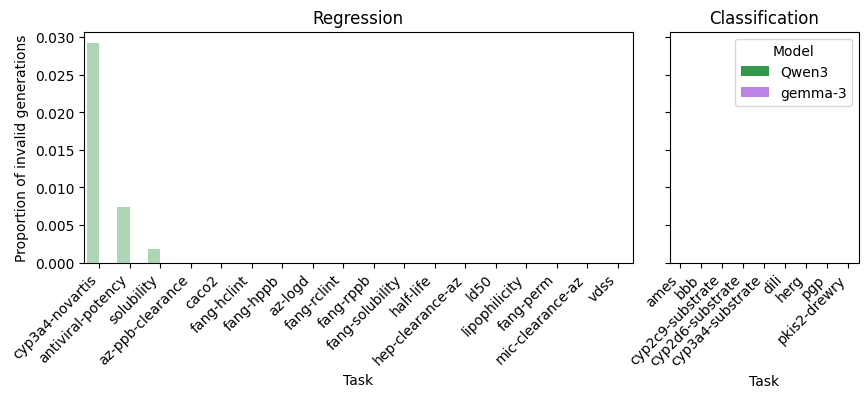

In [31]:
prop_cls = df_validity[df_validity.objectives == "classification"].Task.nunique() / df_validity.Task.nunique()/1.3

fig, axes = plt.subplots(1,2,figsize=(10,3), gridspec_kw={"wspace":0.1, "width_ratios": [1-prop_cls, prop_cls]}, sharey=True)

for obj, ax in zip(["regression", "classification"], axes):
    df_obj = df_validity[df_validity.objectives == obj]
    x_order = df_obj.groupby("Task").validity.mean().sort_values().index.tolist()
    df_obj["missed"] = 1- df_obj["validity"]
    df_obj["missed-and-numeric"] =1 - df_obj["non-valid-and-numeric"]
    kwargs = dict( data=df_obj, x="Task", hue="Model", palette=CMAP_MODELS, order=x_order, ax=ax,)
    sns.barplot(
        y="missed-and-numeric",
        legend=obj == "classification",
        alpha = 1,
        **kwargs
    )
    sns.barplot(
        y="missed",
        legend=False,
        alpha = 0.4,
        **kwargs
    )
    ax.set_title(obj.capitalize())
    _ = ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    if ax == axes[0]:
        ax.set_ylabel("Proportion of invalid generations")
    else:
        ax.set_ylabel("")

fig.savefig(f"{FIG_PATH}/valid_.pdf", bbox_inches="tight")

# Metric Computation

## Regression

In [32]:
# Compute Spearman_corr
df = full_df[full_df.objectives == "regression"]
def get_yagg(values):
    values = [v for v in values if not np.isnan(v)]
    if len(values) == 0:
        return np.nan
    return np.mean(values)

df["y_agg"] = df.groupby(["Model", "prompt_id"]).y.transform(get_yagg)
correlations = df[df.validity == 1].groupby(["Model", "Task"])[["gt", "y_agg"]].corr(method="spearman").loc[pd.IndexSlice[:, :, "gt"], "y_agg"]
correlations = correlations.reset_index(level=2, drop=True)

coverage = df.groupby(["Model", "Task"]).validity.mean()

corr_cov_score = (correlations+1) * coverage / 2
corr_cov_score.fillna(0, inplace=True)

corr_cov_score

Model    Task             
Qwen3    antiviral-potency    0.479586
         az-logd              0.702914
         az-ppb-clearance     0.557226
         caco2                0.727527
         cyp3a4-novartis      0.373522
         fang-hclint          0.516887
         fang-hppb            0.701398
         fang-perm            0.563167
         fang-rclint          0.471889
         fang-rppb            0.506945
         fang-solubility      0.582948
         half-life            0.487598
         hep-clearance-az     0.478533
         ld50                 0.318160
         lipophilicity        0.657328
         mic-clearance-az     0.463299
         solubility           0.876895
         vdss                 0.635331
gemma-3  antiviral-potency    0.688412
         az-logd              0.678306
         az-ppb-clearance     0.587428
         caco2                0.724261
         cyp3a4-novartis      0.564612
         fang-hclint          0.476418
         fang-hppb            0.65951

## Classification

In [41]:
df = full_df[full_df.objectives == "classification"]

def get_yagg(values):
    values = [v for v in values if not np.isnan(v)]
    if len(values) == 0:
        return np.nan
    return np.round(np.mean(values) + 1e-8 * values[0]).clip(0,1)

df["y_agg"] = df.groupby(["Model", "Task", "prompt_id"]).y.transform(get_yagg)

roc_auc = df[df.validity == 1].groupby(
    ["Model", "Task"]
)[["gt", "y_agg"]].apply(
    lambda x: roc_auc_score(
        x["gt"],
        x["y_agg"], )
)
coverage = df.groupby(["Model", "Task"]).validity.mean()
roc_auc = roc_auc * coverage
roc_auc.fillna(0, inplace=True)

roc_auc

Model    Task            
Qwen3    ames                0.706728
         bbb                 0.615272
         cyp2c9-substrate    0.604366
         cyp2d6-substrate    0.648125
         cyp3a4-substrate    0.559699
         dili                0.681944
         herg                0.740410
         pgp                 0.663801
         pkis2-drewry        0.546935
gemma-3  ames                0.604344
         bbb                 0.658456
         cyp2c9-substrate    0.522727
         cyp2d6-substrate    0.511042
         cyp3a4-substrate    0.529412
         dili                0.513889
         herg                0.693548
         pgp                 0.517241
         pkis2-drewry        0.500000
dtype: float64

## Add to table

In [42]:
# Join regression metrics
reg_metric = corr_cov_score.reset_index().rename(columns={0: "Metric"})
cls_metric = roc_auc.reset_index().rename(columns={0: "Metric"})

full_df = full_df.drop(columns=["Metric"], errors="ignore")
full_df = full_df.merge(
    pd.concat([reg_metric, cls_metric]),
    on=["Model", "Task"],
    how="left"
)
full_df

,prompt_id,reward,gt,y,norm_var,model,n_props,properties,objectives,validity,Task,match,contains_numeric,Model,Metric
0,asap-discovery:antiviral-potency-2025-unblinde...,-3.017380,4.600,6.5,0.947943,Qwen3-30B-A3B-Thinking-2507,1,asap-discovery/antiviral-potency-2025-unblinded,regression,True,antiviral-potency,\boxed{6.5},True,Qwen3,0.479586
1,asap-discovery:antiviral-potency-2025-unblinde...,0.000000,4.600,NaN,0.947943,Qwen3-30B-A3B-Thinking-2507,1,asap-discovery/antiviral-potency-2025-unblinded,regression,False,antiviral-potency,\boxed{\text{cannot predict}},False,Qwen3,0.479586
2,asap-discovery:antiviral-potency-2025-unblinde...,-3.017380,4.600,6.5,0.947943,Qwen3-30B-A3B-Thinking-2507,1,asap-discovery/antiviral-potency-2025-unblinded,regression,True,antiviral-potency,\boxed{6.5},True,Qwen3,0.479586
3,asap-discovery:antiviral-potency-2025-unblinde...,-1.848890,4.600,6.2,0.947943,Qwen3-30B-A3B-Thinking-2507,1,asap-discovery/antiviral-potency-2025-unblinded,regression,True,antiviral-potency,\boxed{6.2},True,Qwen3,0.479586
4,asap-discovery:antiviral-potency-2025-unblinde...,0.098593,4.600,5.5,0.947943,Qwen3-30B-A3B-Thinking-2507,1,asap-discovery/antiviral-potency-2025-unblinded,regression,True,antiviral-potency,\boxed{5.5},True,Qwen3,0.479586
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134245,novartis:novartis-cyp3a4-v1_train_9807,-100.000000,-1.354,2.5,0.311549,gemma-3-27b-it,1,novartis/novartis-cyp3a4-v1,regression,True,cyp3a4-novartis,\boxed{2.5},True,gemma-3,0.564612
134246,novartis:novartis-cyp3a4-v1_train_9807,-100.000000,-1.354,2.0,0.311549,gemma-3-27b-it,1,novartis/novartis-cyp3a4-v1,regression,True,cyp3a4-novartis,\boxed{2.0},True,gemma-3,0.564612
134247,novartis:novartis-cyp3a4-v1_train_9807,-100.000000,-1.354,2.5,0.311549,gemma-3-27b-it,1,novartis/novartis-cyp3a4-v1,regression,True,cyp3a4-novartis,\boxed{2.5},True,gemma-3,0.564612
134248,novartis:novartis-cyp3a4-v1_train_9807,-100.000000,-1.354,2.2,0.311549,gemma-3-27b-it,1,novartis/novartis-cyp3a4-v1,regression,True,cyp3a4-novartis,\boxed{2.2},True,gemma-3,0.564612


# Plots

In [43]:
KEY = "Metric"
table = full_df.groupby(["Model", "Task", "objectives"])[KEY].mean().reset_index()
MODEL_ORDER = list(CMAP_MODELS.keys())

task_order = table.groupby(["Model", "Task"])[KEY].mean().reset_index().groupby("Task")[KEY].max().sort_values( ascending=False).index

table = table.set_index(["Task"]).loc[task_order].reset_index()
table

,Task,Model,objectives,Metric
0,solubility,Qwen3,regression,0.876895
1,solubility,gemma-3,regression,0.717427
2,herg,Qwen3,classification,0.740410
3,herg,gemma-3,classification,0.693548
4,caco2,Qwen3,regression,0.727527
5,caco2,gemma-3,regression,0.724261
6,ames,Qwen3,classification,0.706728
7,ames,gemma-3,classification,0.604344
8,az-logd,Qwen3,regression,0.702914
9,az-logd,gemma-3,regression,0.678306


# Heatmap

In [44]:
MODEL_ORDER = full_df[full_df.objectives == "regression"].groupby("Model")[KEY].mean().sort_values().index.tolist()

In [45]:
def plot_heatmap(table, axes, title_name, split_val, vmin=0, vmax=1, annot_size=10):
    ax = axes[0]
    pivoted = pd.pivot_table(table[table.objectives == split_val], KEY, "Model", "Task")
    col_order = pivoted.max().sort_values(ascending=False).index
    pivoted = pivoted.loc[MODEL_ORDER,col_order]
    sns.heatmap(
        pivoted,
        ax=ax,
        vmin=vmin,
        vmax=vmax,
        cbar=False,
        annot=True,
        fmt=".2f",
        annot_kws={"size": annot_size}
    )
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticklabels(rotation=90, ha='center', labels=ax.get_xticklabels())
    ax.set_title(title_name)

    ax = axes[1]
    pivoted = pd.pivot_table(table[table.objectives == split_val], KEY, "Model", "objectives")
    pivoted = pivoted.loc[MODEL_ORDER]
    sns.heatmap(
        pivoted,
        ax=ax,
        vmin=vmin,
        vmax=vmax,
        cbar=False,
        annot=True,
        fmt=".2f",
        annot_kws={"size": annot_size}
    )
    ax.set_xlabel("")
    ax.set_xticklabels(rotation=90, ha='center', labels=["Avg."])
    ax.set_title(f"Avg.\n{title_name}")


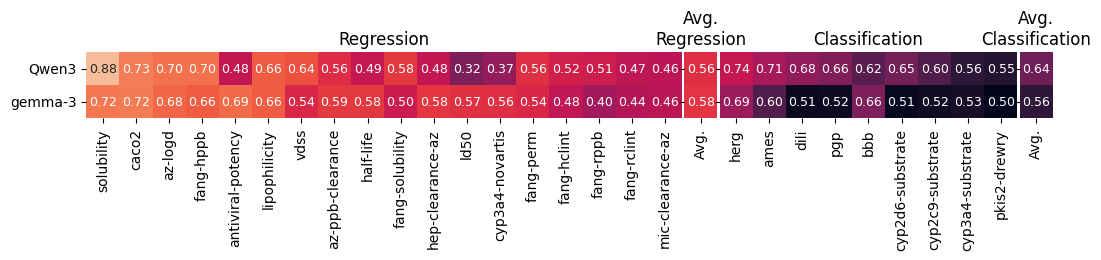

In [46]:
n_tot_cols = table.Task.nunique() + 2
n_rows = table.Model.nunique()

reg_ratio = table[table.objectives == "regression"].Task.nunique() / n_tot_cols
cls_ratio = table[table.objectives == "classification"].Task.nunique() / n_tot_cols

fig, axes = plt.subplots(
    1,
    4,
    figsize = (0.43*n_tot_cols,0.43 * n_rows),
    sharey=True,
    gridspec_kw = {
        "width_ratios":[reg_ratio, 1/n_tot_cols, cls_ratio,  1/n_tot_cols],
        "wspace":0.01,
    }
)

plot_heatmap(table, [axes[0],axes[1]], "Regression", "regression", annot_size=9)
plot_heatmap(table, [axes[2],axes[3]], "Classification", "classification", vmin = 0.5, vmax=1, annot_size= 9)

for ax in axes[1:]:
    ax.set_ylabel("")

fig.savefig(f"{FIG_PATH}/molecular_proppred_heatmap.pdf", bbox_inches="tight")

# Radar Charts

In [47]:
REMOVE_MODELS = [
    # "ether0", "R1-Llama", "R1-Qwen", "MiniMax-M2", "Qwen3"
]
TO_HIGHLIGHT = [
    "RL-Mistral", #"Qwen3-Next"
]

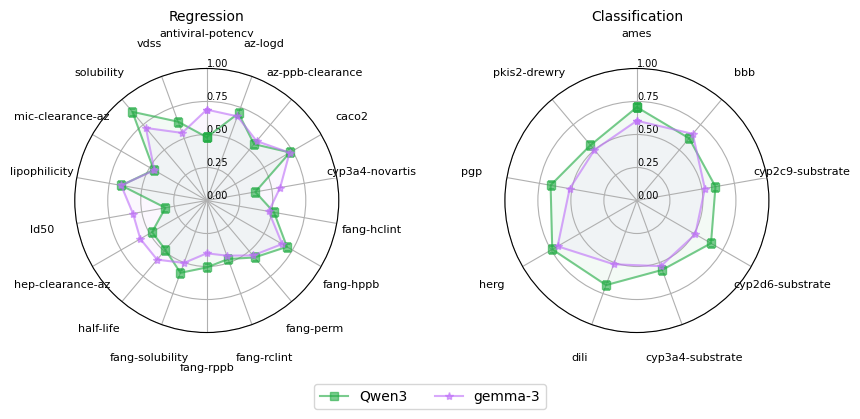

In [48]:
# Radar charts for classification and regression
from math import pi
from notebooks.utils import CMAP_MODELS, MARKER_MODELS


def plot_radar(ax, table, split_val, title, vmin=0, vmax=1):
    model_order = [m for m in CMAP_MODELS.keys() if not m in REMOVE_MODELS and m in table.Model.unique()]
    data = pd.pivot_table(table[table.objectives == split_val], KEY, "Model", "Task")
    categories = data.columns.tolist()
    n_cats = len(categories)

    # Compute angle for each category
    angles = [n / float(n_cats) * 2 * pi for n in range(n_cats)]
    angles += angles[:1]  # Complete the loop

    ax.set_theta_offset(pi / 2)
    ax.set_theta_direction(-1)

    # Draw category labels
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, size=8, zorder=120)

    # Move labels further from the plot to avoid overlap with grid
    ax.tick_params(axis='x', pad=15)

    # Draw ylabels
    ax.set_rlabel_position(0)
    yticks = np.linspace(vmin, vmax, 5)
    ax.set_yticks(yticks)
    ax.set_yticklabels([f"{y:.2f}" for y in yticks], size=7)
    ax.set_ylim(vmin, vmax)

    # Plot each model
    for model in [m for m in CMAP_MODELS if m in model_order]:
        values = data.loc[model].tolist()
        values += values[:1]  # Complete the loop
        color = CMAP_MODELS.get(model, None)
        marker = MARKER_MODELS[model]  # Default to circle if not in MARKER_MODELS
        ax.plot(
            angles,
            values,
            linewidth=1.5,
            linestyle='solid',
            label=model,
            color=color,
            marker=marker,
            markersize=6,
            alpha = 1.0 if model in TO_HIGHLIGHT else 0.6
        )
        ax.fill(angles, values, alpha=0.05, color=color)

    ax.set_title(title, size=10, y=1.15)
    # Ensure tick labels are drawn on top
    for label in ax.get_xticklabels():
        label.set_zorder(0)
        label.set_bbox(dict(facecolor='white', edgecolor='none', alpha=1., pad=1.))

fig, axes = plt.subplots(1, 2, figsize=(9, 4), subplot_kw=dict(polar=True))

plot_radar(axes[0], table[~table.Model.isin(REMOVE_MODELS)], "regression", "Regression", vmin=0, vmax=1)
plot_radar(axes[1], table[~table.Model.isin(REMOVE_MODELS)], "classification", "Classification", vmin=0., vmax=1)

# Single legend below both plots
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=6, bbox_to_anchor=(0.5, -0.07))

plt.tight_layout()
fig.savefig(f"{FIG_PATH}/molecular_proppred_radar.pdf", bbox_inches="tight")
plt.show()